# Data Science Lab Winter Project 2024/2025
## Age Detection
Within the field of speech processing, a long-standing task of interest is estimating the age of a speaker based on their vocal characteristics. Some systems are capable of analyzing spoken sentences to extract features that correlate with the speaker’s age. The process of estimating a speaker’s age from their speech is referred to as age estimation. The target (output) of the system is a single value representing the estimated age of the speaker.

Report by:
- Gosmar Dario: s337625
- Maretto Chiara: s339401

# 1 Imports
## 1.1 Library Import

In [1]:
# Import the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os
from scipy.io import wavfile
import librosa

## 1.2 Dataset Import
The dataset is comprised of 3,624 samples: 2,933 samples for the **development set** and 691 samples for the **evaluation set**. Each sample corresponds to a spoken sentence, and the associated speaker’s age is provided as the target label. 
The speech samples have been collected in controlled conditions to ensure consistent feature extraction.

For each sample, a variety of acoustic and linguistic features have been extracted from the speech signal. These features form the dataset and include:
- **sampling rate**: the sampling rate of the audio signal, in Hz
- **age**: the chronological age of the speaker (target label)
- **gender**: the gender of the speake
- **ethnicity**: the ethnicity of the speaker
- **mean pitch**, **max pitch**, **min pitch**: mean, maximum, and minimum pitch of the speech signal, in Hz
- **jitter**: a measure of the variations in pitch, representing voice stability
- **shimmer**: a measure of amplitude variations in the speech signal
- **energy**: the overall energy of the speech signal
- **zcr mean**: the mean zero-crossing rate, indicating the number of times the signal changes sign
- **spectral centroid mean**: the mean spectral centroid, representing the “center of mass” of the frequency spectrum
- **tempo**: the estimated speaking rate, in beats per minute (BPM)
- **hnr**: the harmonic-to-noise ratio, indicating voice quality
- **num words**, **num characters**: the number of words and characters in the spoken sentence
- **num pauses**: the number of pauses detected in the speech
- **silence duration**: the total duration of silence within the speech signal, in seconds
- **path**: the file path to the audio recording

In [2]:
dev_df = pd.read_csv("DSL_Winter_Project_2025/development.csv")
eval_df = pd.read_csv("DSL_Winter_Project_2025/evaluation.csv")

# 2 Data Exploration

In [3]:
dev_df.info(), dev_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2933 entries, 0 to 2932
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Id                      2933 non-null   int64  
 1   sampling_rate           2933 non-null   int64  
 2   age                     2933 non-null   float64
 3   gender                  2933 non-null   object 
 4   ethnicity               2933 non-null   object 
 5   mean_pitch              2933 non-null   float64
 6   max_pitch               2933 non-null   float64
 7   min_pitch               2933 non-null   float64
 8   jitter                  2933 non-null   float64
 9   shimmer                 2933 non-null   float64
 10  energy                  2933 non-null   float64
 11  zcr_mean                2933 non-null   float64
 12  spectral_centroid_mean  2933 non-null   float64
 13  tempo                   2933 non-null   object 
 14  hnr                     2933 non-null   

(None, (2933, 20))

In [4]:
directory = 'DSL_Winter_Project_2025'
data_list = []
spectograms = []
durations = []
for i in range(dev_df.shape[0]):    
    filename = dev_df['path'][i]   
    file_path = os.path.join(directory, filename)
    if os.path.isfile(file_path):        
        y, sr = librosa.load(file_path, sr = dev_df['sampling_rate'][i])        
        #mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, fmax=8000, n_fft=y.size)    
        #log_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)           
        duration = librosa.get_duration(y=y, sr=sr)
        durations.append(duration)
        #spectograms.append(log_spectrogram)

dev_df['duration'] = durations

In [5]:
# define a copy of the df to work on
df = dev_df.copy() 

In [6]:
df['tempo'] = df['tempo'].str.replace('[', '').str.replace(']', '').astype('float')
df['tempo']

0       151.999081
1       129.199219
2       117.453835
3       117.453835
4       112.347147
           ...    
2928    184.570312
2929     83.354335
2930     89.102909
2931    143.554688
2932     83.354335
Name: tempo, Length: 2933, dtype: float64

## 2.1 Outliers

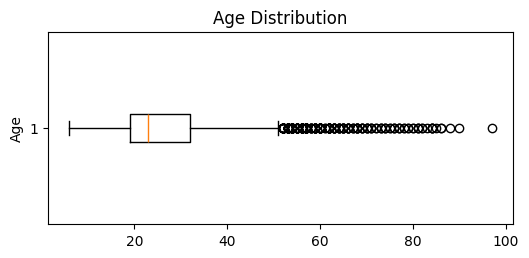

In [7]:
plt.figure(figsize=(6, 2.5))
plt.boxplot(dev_df['age'], vert = False)
plt.title('Age Distribution')
plt.ylabel('Age')
plt.show()

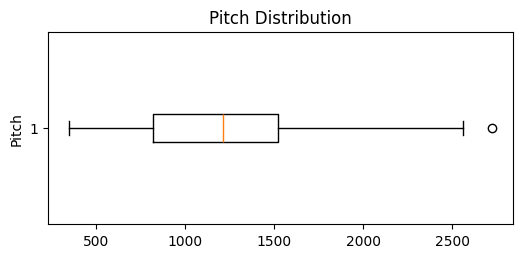

In [8]:
plt.figure(figsize=(6, 2.5))
plt.boxplot(dev_df['mean_pitch'], vert = False)
plt.title('Pitch Distribution')
plt.ylabel('Pitch')
plt.show()

We can try to remove the outlier detected by the *mean_pitch*.

In [9]:
Q1 = df['mean_pitch'].quantile(0.25)
Q3 = df['mean_pitch'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['mean_pitch'] >= (Q1 - 1.5 * IQR)) & (df['mean_pitch'] <= (Q3 + 1.5 * IQR))]
df.shape

(2932, 21)

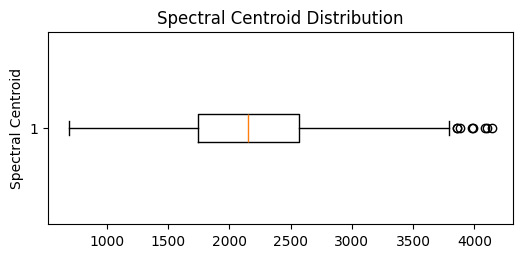

In [10]:
plt.figure(figsize=(6, 2.5))
plt.boxplot(dev_df['spectral_centroid_mean'], vert = False)
plt.title('Spectral Centroid Distribution')
plt.ylabel('Spectral Centroid')
plt.show()

We can try to remove the outlier detected by the *spectral_centroid*.

In [11]:
Q1 = df['spectral_centroid_mean'].quantile(0.25)
Q3 = df['spectral_centroid_mean'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['spectral_centroid_mean'] >= (Q1 - 1.5 * IQR)) & (df['spectral_centroid_mean'] <= (Q3 + 1.5 * IQR))]
df.shape

(2924, 21)

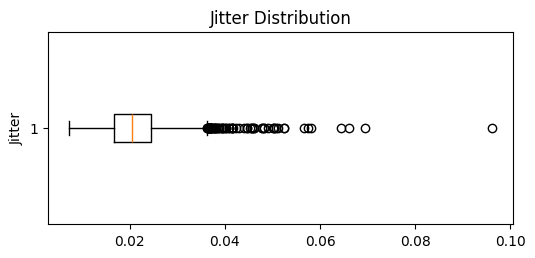

In [12]:
plt.figure(figsize=(6, 2.5))
plt.boxplot(dev_df['jitter'], vert = False)
plt.title('Jitter Distribution')
plt.ylabel('Jitter')
plt.show()

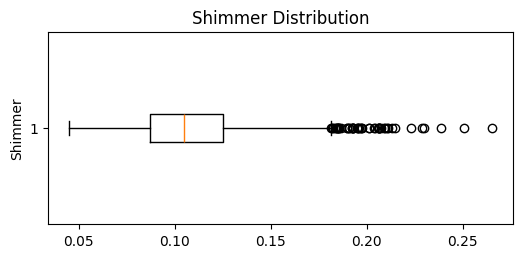

In [13]:
plt.figure(figsize=(6, 2.5))
plt.boxplot(dev_df['shimmer'], vert = False)
plt.title('Shimmer Distribution')
plt.ylabel('Shimmer')
plt.show()

## 2.2 Correlation between features

In [14]:
spearman_corr = dev_df['num_words'].corr(dev_df['num_characters'], method='spearman')
print(f"Spearman's rank correlation: {spearman_corr}")

Spearman's rank correlation: 0.9950099134407278


In [15]:
spearman_corr = dev_df['num_pauses'].corr(dev_df['silence_duration'], method='spearman')
print(f"Spearman's rank correlation: {spearman_corr}")

Spearman's rank correlation: 0.7378261155278655


We can see that *num_words* and *num_characters* are very higly correlated. We decide to remove *num_characters* from the dataset. The same holds for *num_pauses* and *silence_duration* and we decided to keep *silence_duration*. 

In [16]:
df = df.drop(columns=['num_pauses', 'num_characters'], axis=1)

## 2.3 Categorical features

In [17]:
dev_df['gender'].unique().size, dev_df['ethnicity'].unique().size

(2, 165)

The cardinality of _ethinicity_ is too high to perform 1he, insted we perforiton _gender_.

In [18]:
encoded_df = pd.get_dummies(df, columns=['gender'])

## 2.4 Feature Selection

We try to perform iterative feature selection using a Random Forest Regressor with default hyperparamters.

In [19]:
df_dropped = encoded_df.drop(columns=['ethnicity','path', 'Id']) # drop non-numeric columns
feature_names = df_dropped.drop(columns=["age"]).columns
X = df_dropped.drop(columns=["age"])
y = df_dropped["age"]
X_train, X_valid, y_train, y_valid = train_test_split(X,y, shuffle=True, random_state=42)

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
reg = RandomForestRegressor(random_state=42)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_valid)
r2 = r2_score(y_valid, y_pred)
rmse = root_mean_squared_error(y_valid, y_pred)
r2,rmse

(0.31162946337993325, np.float64(11.24919438130812))

In [21]:
ndx = np.argsort(reg.feature_importances_)
for i, j in zip(feature_names[ndx], reg.feature_importances_[ndx]): print(i, j)

sampling_rate 0.0
num_words 0.0013473480315060462
gender_male 0.005888885361408401
gender_female 0.0062590819091023755
tempo 0.04452021463151994
zcr_mean 0.04752646551837799
min_pitch 0.05448887789812388
spectral_centroid_mean 0.055131419627358944
hnr 0.05548020710922039
shimmer 0.057777192627576704
max_pitch 0.05882762607675151
mean_pitch 0.06041555223395331
energy 0.06391864648276051
silence_duration 0.06867021785850264
jitter 0.07941597448030742
duration 0.34033229015352995


Try to remove also *sampling_rate*, *num_words* and the *gender*.

In [22]:
df_dropped = encoded_df.drop(columns=['ethnicity','path', 'Id', 'sampling_rate', 'num_words']) # drop non-numeric columns
feature_names = df_dropped.drop(columns=["age"]).columns
X = df_dropped.drop(columns=["age"])
y = df_dropped["age"]
X_train, X_valid, y_train, y_valid = train_test_split(X,y, shuffle=True, random_state=42)

In [23]:
reg = RandomForestRegressor(random_state=42)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_valid)
r2 = r2_score(y_valid, y_pred)
rmse = root_mean_squared_error(y_valid, y_pred)
r2,rmse

(0.3005631813528957, np.float64(11.339255197845247))

In [24]:
ndx = np.argsort(reg.feature_importances_)
for i, j in zip(feature_names[ndx], reg.feature_importances_[ndx]): print(i, j)

gender_male 0.005007033567843897
gender_female 0.006996248181068588
tempo 0.044118277197724404
zcr_mean 0.04718926540574824
spectral_centroid_mean 0.05506124869893151
min_pitch 0.055645184184909754
hnr 0.05577910703572524
shimmer 0.057523385367695204
max_pitch 0.058802685341141823
mean_pitch 0.061160294142702624
energy 0.06342283209784091
silence_duration 0.06888141252538224
jitter 0.08018825516708472
duration 0.34022477108620086


Try to summarize pitch range.

In [25]:
df['pitch_range'] = df['max_pitch'] - df['min_pitch']

In [26]:
spearman_corr = df['pitch_range'].corr(df['jitter'], method='spearman')
print(f"Spearman's rank correlation: {spearman_corr}")

Spearman's rank correlation: 0.3334786731155163


In [27]:
df_dropped = df.drop(columns=['ethnicity','path', 'Id', 'max_pitch','min_pitch', 'mean_pitch', 'sampling_rate', 'num_words', 'gender']) # drop non-numeric columns
feature_names = df_dropped.drop(columns=["age"]).columns
X = df_dropped.drop(columns=["age"])
y = df_dropped["age"]
X_train, X_valid, y_train, y_valid = train_test_split(X,y, shuffle=True, random_state=42)

In [28]:
reg = RandomForestRegressor(random_state=42)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_valid)
r2 = r2_score(y_valid, y_pred)
rmse = root_mean_squared_error(y_valid, y_pred)
r2,rmse

(0.2953044707382443, np.float64(11.381802428551104))

In [29]:
ndx = np.argsort(reg.feature_importances_)
for i, j in zip(feature_names[ndx], reg.feature_importances_[ndx]): print(i, j)

tempo 0.05410774883144067
spectral_centroid_mean 0.06599217984375648
zcr_mean 0.067318669315371
hnr 0.0688706511507421
pitch_range 0.0721176463024193
shimmer 0.07352620533294905
energy 0.07865805238158922
silence_duration 0.08221183520661966
jitter 0.08930748805881711
duration 0.3478895235762953


In [30]:
df['voice_silence_ratio'] = (df['duration'] - df['silence_duration'])/ df['silence_duration']

In [31]:
df_dropped = df.drop(columns=['ethnicity','path', 'Id', 'max_pitch','min_pitch', 'mean_pitch', 'sampling_rate', 'num_words', 'gender', 'silence_duration', 'duration']) # drop non-numeric columns
feature_names = df_dropped.drop(columns=["age"]).columns
X = df_dropped.drop(columns=["age"])
y = df_dropped["age"]
X_train, X_valid, y_train, y_valid = train_test_split(X,y, shuffle=True, random_state=42)

In [32]:
reg = RandomForestRegressor(random_state=42)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_valid)
r2 = r2_score(y_valid, y_pred)
rmse = root_mean_squared_error(y_valid, y_pred)
r2,rmse

(0.22825379122388156, np.float64(11.91098113606948))

In [33]:
ndx = np.argsort(reg.feature_importances_)
for i, j in zip(feature_names[ndx], reg.feature_importances_[ndx]): print(i, j)

tempo 0.06111852173952862
shimmer 0.07702315663371367
spectral_centroid_mean 0.08459195291109349
zcr_mean 0.08848892191350627
energy 0.0891672247081217
jitter 0.10000440889432233
voice_silence_ratio 0.11670217536454841
hnr 0.18848215856031125
pitch_range 0.19442147927485412


# 3 Data Preprocessing

# 4 Model Selection

# 5 Hyperparameter Tuning

# 6 Evaluation